# ENG2440 Assignment 1: Pneumonia Classification Challenge

Name: Md Aman Khan
Student ID: 25011138

### Part A. Define the task and inspect the data

State the input, output and clinical question in your own words.

Input:  
Chest radiograph images taken from a frontal view. The images are in DICOM file format (a medical imaging file format containing image pixels and associated information such as image dimensions and/or the projection view, etc.).

Output:  
Prediction of whether the target lung opacity consistent with possible pneumonia is present. The model will produce a probability of whether the given image belongs to the positive class (the image has annotated lung opacity and therefore is consistent with possible pneumonia) or negative class (the image has no annotated lung opacity and is normal/may have other abnormalities).

Clinical question:  
Does a frontal chest X-ray show lung opacity consistent with possible pneumonia?

Load the DICOM images, label file and supplied RSNA-to-NIH mapping file. Report the numbers of unique
examinations and source patients, plus the class counts and class proportions.

Imports

In [124]:
from scripts.preprocessing import dicom_to_tensor
from scripts.evaluation import calculate_metrics
from scripts.training import train_model
from scripts.curves import calculate_curves
from scripts.gradcam import generate_gradcam
from scripts.image_masks import mask_border, mask_control_region

from pathlib import Path
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

import numpy as np
import torch
import torch.nn as nn

from torchvision import transforms

import torchvision.models as models
from torchvision.models import ResNet18_Weights

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

In [24]:
# Checkpoints
CHECKPOINT_DIR = Path("checkpoints")
E2_CHECKPOINT = CHECKPOINT_DIR / "resnet18_e2_complete.pt"
E5_CHECKPOINT = CHECKPOINT_DIR / "resnet18_e5_seed_results.pt"

In [25]:
# Magic helper
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skipif(line, cell):
    if eval(line):
        print(f"Skipping cell execution because condition '{line}' is True.")
        return
    get_ipython().run_cell(cell) # type: ignore

Read files and begin EDA

In [26]:
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

dicom_files = list(DATA_ROOT.rglob("*.dcm"))

print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [27]:
labels = pd.read_csv(LABEL_FILE)

print("Label file shape:", labels.shape)
print("Label columns:", labels.columns.tolist())

Label file shape: (28989, 9)
Label columns: ['patientId', 'x', 'y', 'width', 'height', 'Target', 'StudyInstanceUID', 'SeriesInstanceUID', 'SOPInstanceUID']


In [28]:
mapping = pd.read_csv(MAPPING_FILE)

print("Mapping file shape:", mapping.shape)
print("Mapping columns:", mapping.columns.tolist())

Mapping file shape: (25684, 3)
Mapping columns: ['patientId', 'nih_patient_id', 'nih_image_id']


In [29]:
# Unique examination counts
examination_count = labels["patientId"].nunique()
print("Unique examinations: ", examination_count)

Unique examinations:  25684


In [30]:
# Unique source patients
source_patient_count = mapping["nih_patient_id"].nunique()
print("Unique source patients: ", source_patient_count)

Unique source patients:  11171


In [31]:
exam_labels = labels.groupby("patientId", as_index=False)["Target"].max()
print("Examinations after grouping together: ", len(exam_labels))

Examinations after grouping together:  25684


In [32]:
class_counts = exam_labels["Target"].value_counts()

print("Class counts for positive and negative cases:")
print(class_counts)

Class counts for positive and negative cases:
Target
0    20025
1     5659
Name: count, dtype: int64


In [33]:
class_proportions = class_counts / len(exam_labels)
print("Class proportions:")
print(class_proportions)

Class proportions:
Target
0    0.779668
1    0.220332
Name: count, dtype: float64


Display at least six representative images: positive and negative examples, including at least one difficult or
unusual example

In [34]:
image_ids = labels[["patientId", "SOPInstanceUID"]].drop_duplicates()

image_table = exam_labels.merge(
    image_ids,
    on="patientId",
    how="left",
    validate="one_to_one"
)

path_by_uid = {
    path.stem: path for path in dicom_files
}

In [35]:
selected_examples = image_table.groupby("Target").sample(
    n=3,
    random_state=42
)

In [36]:
# using the smallest positive case as a difficult example
positive_cases = labels[labels["Target"] == 1].copy()
positive_cases["bbox_area"] = positive_cases["width"].fillna(0) * positive_cases["height"].fillna(0)

difficult_case = positive_cases.nsmallest(1, "bbox_area").iloc[0]

first_positive_idx = selected_examples[selected_examples["Target"] == 1].index[0]
selected_examples.loc[first_positive_idx, ["patientId", "Target", "SOPInstanceUID"]] = [
    difficult_case["patientId"],
    difficult_case["Target"],
    difficult_case["SOPInstanceUID"]
]

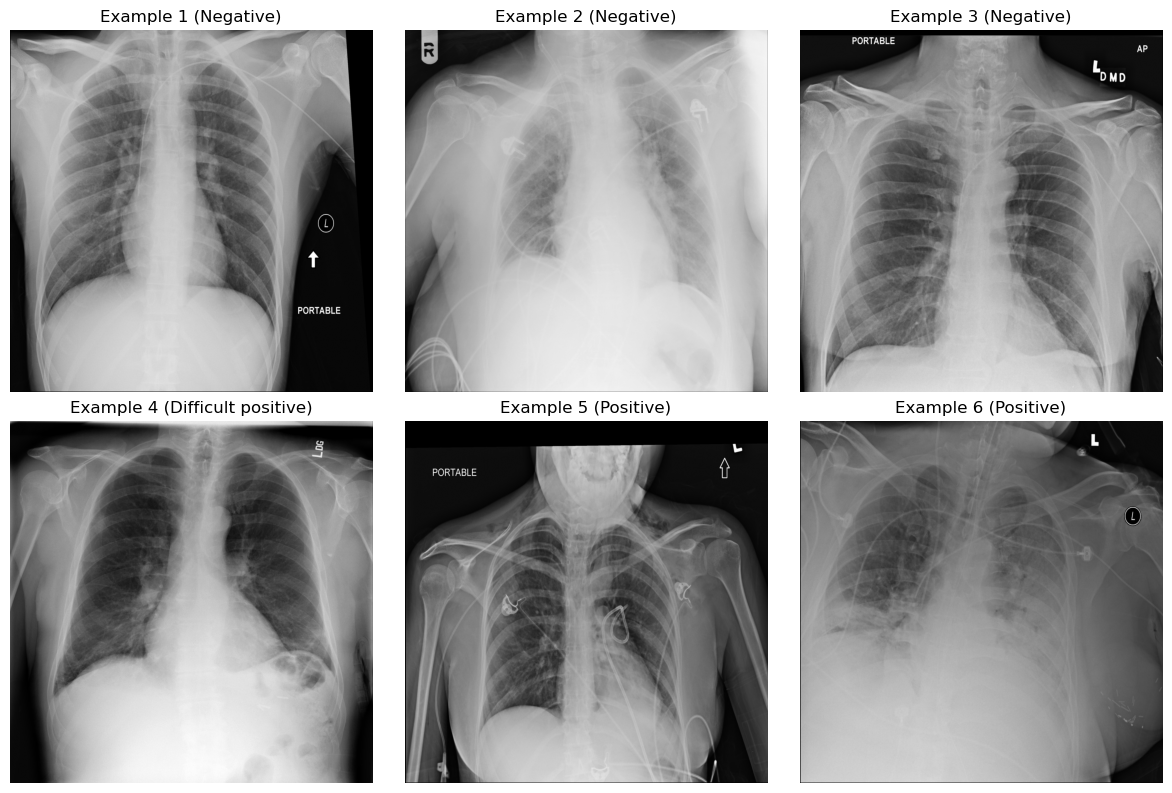

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for number, (ax, row) in enumerate(
    zip(axes.flatten(), selected_examples.itertuples(index=False)),
    start=1
):
    dicom = pydicom.dcmread(path_by_uid[row.SOPInstanceUID])

    colour_map = "gray_r" if dicom.PhotometricInterpretation == "MONOCHROME1" else "gray"
    ax.imshow(dicom.pixel_array, cmap=colour_map)

    class_name = "Positive" if row.Target == 1 else "Negative"

    if (
        row.patientId == difficult_case["patientId"]
        and row.SOPInstanceUID == difficult_case["SOPInstanceUID"]
    ):
        ax.set_title(f"Example {number} (Difficult positive)")
    else:
        ax.set_title(f"Example {number} ({class_name})")

    ax.axis("off")

plt.tight_layout()
plt.show()

Check image size, photometric interpretation and projection/view information when available. 

In [38]:
def dicom_summary(path):
    ds = pydicom.dcmread(path)

    rows = ds.get("Rows", None)
    cols = ds.get("Columns", None)
    photometric = ds.get("PhotometricInterpretation", "N/A")
    view_position = ds.get("ViewPosition", "N/A")
    body_part = ds.get("BodyPartExamined", "N/A")

    print(f"\n\nDICOM Summary for file: {path}")
    print(f"Image size: {rows} x {cols}")
    print(f"PhotometricInterpretation: {photometric}")
    print(f"ViewPosition: {view_position}")
    print(f"BodyPartExamined: {body_part}")

In [39]:
for _, row in selected_examples.iterrows():
    uid = str(row.SOPInstanceUID)
    path = path_by_uid.get(uid)

    if path is None:
        print(f"File not found for UID: {uid}")
        continue

    dicom_summary(path)



DICOM Summary for file: data/images/1.2.276.0.7230010.3.1.2.8323329.11301.1517874357.690168/1.2.276.0.7230010.3.1.3.8323329.11301.1517874357.690167/1.2.276.0.7230010.3.1.4.8323329.11301.1517874357.690169.dcm
Image size: 1024 x 1024
PhotometricInterpretation: MONOCHROME2
ViewPosition: AP
BodyPartExamined: CHEST


DICOM Summary for file: data/images/1.2.276.0.7230010.3.1.2.8323329.16394.1517874397.310615/1.2.276.0.7230010.3.1.3.8323329.16394.1517874397.310614/1.2.276.0.7230010.3.1.4.8323329.16394.1517874397.310616.dcm
Image size: 1024 x 1024
PhotometricInterpretation: MONOCHROME2
ViewPosition: AP
BodyPartExamined: CHEST


DICOM Summary for file: data/images/1.2.276.0.7230010.3.1.2.8323329.23637.1517874449.158547/1.2.276.0.7230010.3.1.3.8323329.23637.1517874449.158546/1.2.276.0.7230010.3.1.4.8323329.23637.1517874449.158548.dcm
Image size: 1024 x 1024
PhotometricInterpretation: MONOCHROME2
ViewPosition: AP
BodyPartExamined: CHEST


DICOM Summary for file: data/images/1.2.276.0.7230010.3.

### Part B. Create leakage-safe splits 

Create training, validation and test splits using the original anonymized NIH patient identifier from the supplied mapping file as the grouping unit. 

In [40]:
# merging patient labels with NIH mapping
patient_level = exam_labels.merge(
    mapping[["patientId", "nih_patient_id"]],
    on="patientId",
    how="left",
    validate="one_to_one"
)

assert patient_level["nih_patient_id"].notna().all(), "Missing NIH patient mapping"

In [41]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(
    gss.split(patient_level, groups=patient_level["nih_patient_id"])
)

In [42]:
train_df = patient_level.iloc[train_idx].copy().reset_index(drop=True)
test_df = patient_level.iloc[test_idx].copy().reset_index(drop=True)

gss_val = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=42)
train_idx2, val_idx = next(
    gss_val.split(train_df, groups=train_df["nih_patient_id"])
)

final_train_df = train_df.iloc[train_idx2].copy().reset_index(drop=True)
val_df = train_df.iloc[val_idx].copy().reset_index(drop=True)

Use assertions to demonstrate that the three patient-identifier sets are disjoint.

In [43]:
train_patients = set(final_train_df["nih_patient_id"])
val_patients = set(val_df["nih_patient_id"])
test_patients = set(test_df["nih_patient_id"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

Report the size and positive-class proportion of every split. 

In [44]:
print("Train size:", len(final_train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain positive rate:", final_train_df["Target"].mean())
print("Validation positive rate:", val_df["Target"].mean())
print("Test positive rate:", test_df["Target"].mean())

Train size: 15340
Validation size: 5180
Test size: 5164

Train positive rate: 0.21616688396349412
Validation positive rate: 0.21640926640926642
Test positive rate: 0.23663826491092177


State one further leakage route that patient-level grouping alone would not prevent in a multi-site dataset, and explain how you would test for it.

Patient-level grouping will not prevent leakage that can be caused by scanner specific information. For example, images from the same hospital, scanner, preprocessing pipeline, etc. could appear in both the training and test sets. The model will then learn site-specific image characteristics such as image borders, markers, contrast, compression patterns, etc. and will not be clinically relevant to lung features.

To test for this, I will identify any available metadata such as hospital, scanner, manufacturer, etc. and compare these across the splits. If the site information is available, I would group the data by site as well as patient or use a leave-one-site-out evaluation system in which entire sites are held out for testing. I will also compare model performance across different sites. A large drop on an unseen site would suggest that the model has indeed learned site-specific shortcuts and is not generalising reliable to new hospitals.

### Part C. Preprocess and augment

Convert the DICOM pixel data to a model-ready tensor, resize the images consistently and document the intensity scaling or normalization. 

Tensor shape: (1, 224, 224)
Tensor dtype: torch.float64
Tensor intensity range: (0.0, 0.9999999999541284)


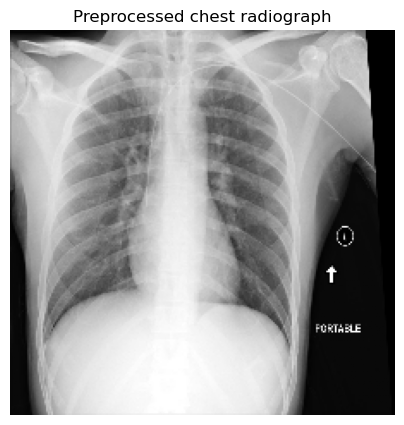

In [45]:
TARGET_SIZE = (224, 224)

sample_uid = str(selected_examples.iloc[0]["SOPInstanceUID"])
sample_tensor = dicom_to_tensor(path_by_uid[sample_uid], target_size=TARGET_SIZE)

print("Tensor shape:", tuple(sample_tensor.shape))
print("Tensor dtype:", sample_tensor.dtype)
print(
    "Tensor intensity range:",
    (sample_tensor.min().item(), sample_tensor.max().item())
)

plt.figure(figsize=(5, 5))
plt.imshow(sample_tensor.squeeze(0), cmap="gray")
plt.title("Preprocessed chest radiograph")
plt.axis("off")
plt.show()

DICOM images were converted to one-channel PyTorch tensors. Images were resized to 224x224 pixels. Intensisites were clipped between the 1st and 99th percentiles to reduce the influence of extreme values, and scaled to the range [0, 1]. MONOCHROME1 images were inverted so that the grayscale interpretation was consistent.

Apply safe training-only augmentation. Show a small before-and-after panel and justify each transformation.

In [46]:
training_augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
        fill=0
    ),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    )
])

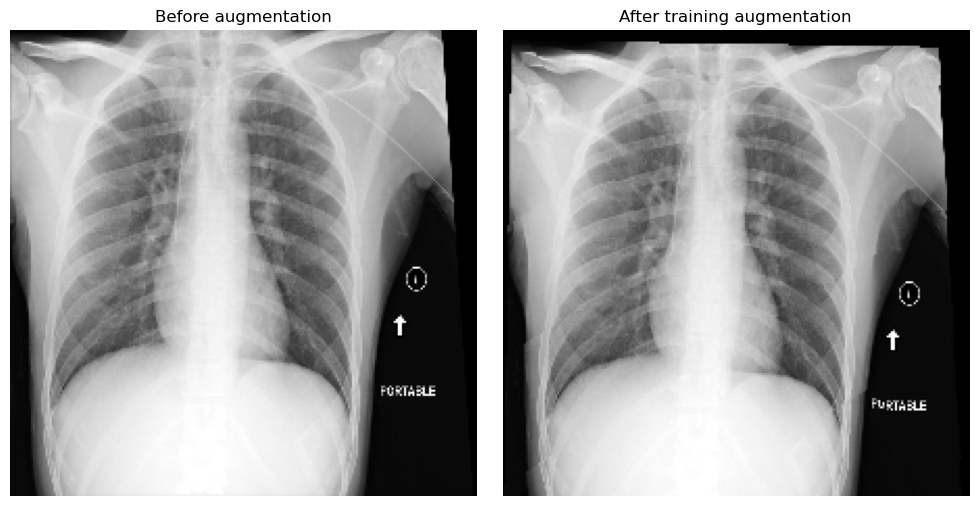

In [47]:
sample_uid = str(selected_examples.iloc[0]["SOPInstanceUID"])
sample_path = path_by_uid[sample_uid]

original_tensor = dicom_to_tensor(sample_path)
augmented_tensor = training_augmentation(original_tensor)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_tensor.squeeze(0), cmap="gray")
axes[0].set_title("Before augmentation")
axes[0].axis("off")

axes[1].imshow(augmented_tensor.squeeze(0), cmap="gray")
axes[1].set_title("After training augmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Training-only augmentation is used and small affine changes, mild brightness changes and contrast adjustments are used. Rotation is limited to 5 degrees, translation is limited to 3% of the image size and scaling to 97-103% to simulate minor acquisition differences while preserving the underlying anatomy. Horizontal flipping is not used because it could alter left-right orientation and reverse the position of anatomical or acquisition markers. Validation and test images will not be randomly augmented.

Address class imbalance using a weighted loss, balanced sampling or another justified strategy. Evaluate the model with and without this strategy and report its effect on the metrics. 

In [48]:
training_class_counts = (
    final_train_df["Target"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

negative_count = training_class_counts[0]
positive_count = training_class_counts[1]

positive_weight = negative_count / positive_count

print("Training class counts:")
print(training_class_counts)

print("\nPositive-class weight:", positive_weight)

Training class counts:
Target
0    12024
1     3316
Name: count, dtype: int64

Positive-class weight: 3.62605548854041


In [49]:
unweighted_loss = nn.BCEWithLogitsLoss()

weighted_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([positive_weight], dtype=torch.float32)
)

### C.4 continuation

The class-imbalance strategy is defined using a weighted binary cross-entropy loss. The positive-class weight was calculated from the training split only.

The comparison between weighted and unweighted training will be completed after the simple baseline model has been implemented in Part D. Both versions will be trained using the same data splits and settings, then compared using validation metrics.

### Part D. Implement a simple baseline

Report a trivial baseline: the results obtained by always predicting the majority class. This is the baseline that later models should outperform. 

In [50]:
majority_class = final_train_df["Target"].mode()[0]

print("Majority class:", majority_class)
print("Majority class name:", "Positive" if majority_class == 1 else "Negative")

Majority class: 0
Majority class name: Negative


In [51]:
validation_predictions = [majority_class] * len(val_df)
validation_labels = val_df["Target"].to_numpy()

In [52]:
baseline_metrics = calculate_metrics(
    labels=validation_labels,
    predictions=validation_predictions
)

print("Validation confusion matrix:")
print(baseline_metrics["confusion_matrix"])

print("\nValidation metrics:")
print("Accuracy:", baseline_metrics["accuracy"])
print("Sensitivity:", baseline_metrics["sensitivity"])
print("Specificity:", baseline_metrics["specificity"])
print("Precision:", baseline_metrics["precision"])
print("F1-score:", baseline_metrics["f1"])

Validation confusion matrix:
[[4059    0]
 [1121    0]]

Validation metrics:
Accuracy: 0.7835907335907336
Sensitivity: 0.0
Specificity: 1.0
Precision: 0.0
F1-score: 0.0


Build a simple PyTorch baseline before using a pretrained CNN. One acceptable option is a logistic classifier (nn.Linear) using at least four image-summary features, such as the mean, standard deviation, selected intensity percentiles or coarse histogram bins. Clearly state the features used.

In [53]:
# feature extraction function
def extract_summary_features(image_tensor):
    pixels = image_tensor.flatten()

    features = torch.tensor([
        pixels.mean().item(),
        pixels.std().item(),
        torch.quantile(pixels, 0.10).item(),
        torch.quantile(pixels, 0.50).item(),
        torch.quantile(pixels, 0.90).item(),
        (pixels > 0.75).float().mean().item()
    ], dtype=torch.float32)

    return features

In [54]:
def add_image_paths(split_df):
    split_with_images = split_df.merge(
        image_table[["patientId", "SOPInstanceUID"]],
        on="patientId",
        how="left",
        validate="one_to_one"
    )

    assert split_with_images["SOPInstanceUID"].notna().all()

    split_with_images["image_path"] = (
        split_with_images["SOPInstanceUID"]
        .map(path_by_uid)
    )

    assert split_with_images["image_path"].notna().all()

    return split_with_images

In [55]:
train_features_df = add_image_paths(final_train_df)
val_features_df = add_image_paths(val_df)
test_features_df = add_image_paths(test_df)

In [56]:
# Extract features for each split

def build_feature_matrix(split_df):
    feature_rows = []

    for path in split_df["image_path"]:
        image_tensor = dicom_to_tensor(path)
        feature_rows.append(extract_summary_features(image_tensor))

    return torch.stack(feature_rows)

In [57]:
X_train = build_feature_matrix(train_features_df)
X_val = build_feature_matrix(val_features_df)
X_test = build_feature_matrix(test_features_df)

y_train = torch.tensor(
    train_features_df["Target"].to_numpy(),
    dtype=torch.float32
)

y_val = torch.tensor(
    val_features_df["Target"].to_numpy(),
    dtype=torch.float32
)

y_test = torch.tensor(
    test_features_df["Target"].to_numpy(),
    dtype=torch.float32
)

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Test feature shape:", X_test.shape)

Training feature shape: torch.Size([15340, 6])
Validation feature shape: torch.Size([5180, 6])
Test feature shape: torch.Size([5164, 6])


In [58]:
# standardize features
feature_mean = X_train.mean(dim=0)
feature_std = X_train.std(dim=0).clamp_min(1e-8)

X_train_scaled = (X_train - feature_mean) / feature_std
X_val_scaled = (X_val - feature_mean) / feature_std
X_test_scaled = (X_test - feature_mean) / feature_std

In [59]:
# the pytorch model

class SummaryFeatureClassifier(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.linear = nn.Linear(number_of_features, 1)

    def forward(self, features):
        return self.linear(features).squeeze(1)

In [60]:
simple_model = SummaryFeatureClassifier(
    number_of_features=X_train_scaled.shape[1]
)

print(simple_model)

SummaryFeatureClassifier(
  (linear): Linear(in_features=6, out_features=1, bias=True)
)


In [61]:
# training the model

torch.manual_seed(42)

simple_model = SummaryFeatureClassifier(
    number_of_features=X_train_scaled.shape[1]
)

simple_model, training_losses, validation_losses = train_model(
    model=simple_model,
    x_train=X_train_scaled,
    y_train=y_train,
    x_val=X_val_scaled,
    y_val=y_val,
    criterion=unweighted_loss,
    number_of_epochs=100,
    learning_rate=0.001
)

print("Final training loss:", training_losses[-1])
print("Final validation loss:", validation_losses[-1])

Final training loss: 0.6300463080406189
Final validation loss: 0.635195791721344


In [62]:
simple_model.eval()

with torch.no_grad():
    validation_logits = simple_model(X_val_scaled)
    validation_probabilities = torch.sigmoid(validation_logits).numpy()

simple_validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

In [63]:
# Evaluation metrics for the simple model on the validation set

simple_metrics = calculate_metrics(
    labels=y_val.numpy(),
    predictions=simple_validation_predictions,
    probabilities=validation_probabilities
)

print("Simple baseline validation confusion matrix:")
print(simple_metrics["confusion_matrix"])

print("\nSimple baseline validation metrics:")
print("Accuracy:", simple_metrics["accuracy"])
print("Sensitivity:", simple_metrics["sensitivity"])
print("Specificity:", simple_metrics["specificity"])
print("Precision:", simple_metrics["precision"])
print("F1-score:", simple_metrics["f1"])
print("ROC-AUC:", simple_metrics["roc_auc"])
print("PR-AUC:", simple_metrics["pr_auc"])

Simple baseline validation confusion matrix:
[[3466  593]
 [ 929  192]]

Simple baseline validation metrics:
Accuracy: 0.7061776061776062
Sensitivity: 0.17127564674397858
Specificity: 0.8539049026853905
Precision: 0.2445859872611465
F1-score: 0.20146904512067157
ROC-AUC: 0.4746465987083032
PR-AUC: 0.2266194542329108


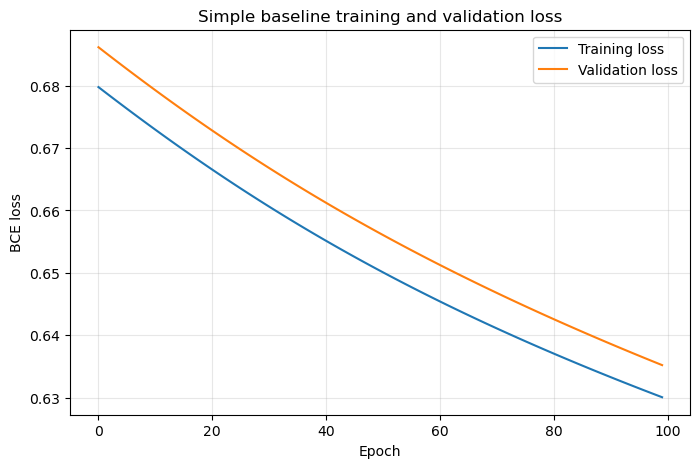

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(training_losses, label="Training loss")
plt.plot(validation_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Simple baseline training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Train using the training split, select settings using the validation split and evaluate the final model once on the test split.

In [65]:
best_epoch = int(np.argmin(validation_losses)) + 1

print("Best epoch selected using validation loss:", best_epoch)
print("Best validation loss:", validation_losses[best_epoch - 1])

Best epoch selected using validation loss: 100
Best validation loss: 0.635195791721344


In [66]:
# retraining the final model
torch.manual_seed(42)

torch.manual_seed(42)

final_simple_model = SummaryFeatureClassifier(
    number_of_features=X_train_scaled.shape[1]
)

final_simple_model, _, _ = train_model(
    model=final_simple_model,
    x_train=X_train_scaled,
    y_train=y_train,
    x_val=X_val_scaled,
    y_val=y_val,
    criterion=unweighted_loss,
    number_of_epochs=best_epoch,
    learning_rate=0.001
)

print("Final model retrained for", best_epoch, "epochs.")

Final model retrained for 100 epochs.


In [67]:
# test predictions
final_simple_model.eval()

with torch.no_grad():
    test_logits = final_simple_model(X_test_scaled)
    test_probabilities = torch.sigmoid(test_logits).numpy()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

test_labels = y_test.numpy()

In [68]:
# test metrics for the final simple model
final_test_metrics = calculate_metrics(
    labels=test_labels,
    predictions=test_predictions,
    probabilities=test_probabilities
)

print("Final simple baseline test confusion matrix:")
print(final_test_metrics["confusion_matrix"])

Final simple baseline test confusion matrix:
[[3424  518]
 [1039  183]]


In [69]:
simple_baseline_test_results = pd.DataFrame([{
    "Model": "Simple feature baseline",
    "Accuracy": final_test_metrics["accuracy"],
    "Sensitivity": final_test_metrics["sensitivity"],
    "Specificity": final_test_metrics["specificity"],
    "Precision": final_test_metrics["precision"],
    "F1-score": final_test_metrics["f1"],
    "ROC-AUC": final_test_metrics["roc_auc"],
    "PR-AUC": final_test_metrics["pr_auc"]
}])

simple_baseline_test_results

,Model,Accuracy,Sensitivity,Specificity,Precision,F1-score,ROC-AUC,PR-AUC
0,Simple feature baseline,0.69849,0.149755,0.868595,0.261056,0.190328,0.497918,0.248675


### C4: Continuation


The simple baseline was trained using both unweighted and weighted binary cross-entropy loss. The same model, training data, validation data, random seed, learning rate and number of epochs were used in both experiments. The only difference was the loss function.

In [70]:
# train the unweighted and weighted models for comparison

torch.manual_seed(42)

unweighted_model = SummaryFeatureClassifier(
    number_of_features=X_train_scaled.shape[1]
)

unweighted_model, unweighted_train_losses, unweighted_val_losses = train_model(
    model=unweighted_model,
    x_train=X_train_scaled,
    y_train=y_train,
    x_val=X_val_scaled,
    y_val=y_val,
    criterion=unweighted_loss,
    number_of_epochs=best_epoch,
    learning_rate=0.001
)

torch.manual_seed(42)

weighted_model = SummaryFeatureClassifier(
    number_of_features=X_train_scaled.shape[1]
)

weighted_model, weighted_train_losses, weighted_val_losses = train_model(
    model=weighted_model,
    x_train=X_train_scaled,
    y_train=y_train,
    x_val=X_val_scaled,
    y_val=y_val,
    criterion=weighted_loss,
    number_of_epochs=best_epoch,
    learning_rate=0.001
)

In [71]:
# validation outputs
def get_model_outputs(model, features):
    model.eval()

    with torch.no_grad():
        logits = model(features)
        probabilities = torch.sigmoid(logits).numpy()

    predictions = (probabilities >= 0.5).astype(int)

    return predictions, probabilities

In [72]:
unweighted_predictions, unweighted_probabilities = get_model_outputs(
    unweighted_model,
    X_val_scaled
)

weighted_predictions, weighted_probabilities = get_model_outputs(
    weighted_model,
    X_val_scaled
)

In [73]:
unweighted_metrics = calculate_metrics(
    labels=y_val.numpy(),
    predictions=unweighted_predictions,
    probabilities=unweighted_probabilities
)

weighted_metrics = calculate_metrics(
    labels=y_val.numpy(),
    predictions=weighted_predictions,
    probabilities=weighted_probabilities
)

In [74]:
# comparison table
class_imbalance_comparison = pd.DataFrame([
    {
        "Strategy": "Unweighted loss",
        "Accuracy": unweighted_metrics["accuracy"],
        "Sensitivity": unweighted_metrics["sensitivity"],
        "Specificity": unweighted_metrics["specificity"],
        "Precision": unweighted_metrics["precision"],
        "F1-score": unweighted_metrics["f1"],
        "ROC-AUC": unweighted_metrics["roc_auc"],
        "PR-AUC": unweighted_metrics["pr_auc"]
    },
    {
        "Strategy": "Weighted loss",
        "Accuracy": weighted_metrics["accuracy"],
        "Sensitivity": weighted_metrics["sensitivity"],
        "Specificity": weighted_metrics["specificity"],
        "Precision": weighted_metrics["precision"],
        "F1-score": weighted_metrics["f1"],
        "ROC-AUC": weighted_metrics["roc_auc"],
        "PR-AUC": weighted_metrics["pr_auc"]
    }
])

class_imbalance_comparison

,Strategy,Accuracy,Sensitivity,Specificity,Precision,F1-score,ROC-AUC,PR-AUC
0,Unweighted loss,0.706178,0.171276,0.853905,0.244586,0.201469,0.474647,0.226619
1,Weighted loss,0.595560,0.322034,0.671101,0.212854,0.256301,0.474844,0.225312


The weighted and unweighted models were trained using the same model, data splits, random seed, learning rate and number of epochs. The only difference was the loss function itself.

Comparing with the unweighted loss, we observe that, the weighted loss increased sensitivity from 0.1713 to 0.3220 and also improved the F1-score from 0.2015 to 0.2563. This implies that the weighted model detected more positive examinations and also produced a better balance between precision and sensitivity. However accuracy also decreased from 0.7062 to 0.5956, specificity decreased from 0.8539 to 0.6711 and precision decreased from 0.2446 to 0.2129.

ROC-AUC mostly remained unchanged, and only increased slightly from 0.4746 to 0.4748 while PR-AUC decreased from 0.2266 to 0.2253. Class weighting mainly changed the classification trade-off at the 0.5 threshold rather than improving the overall discrimination.

### Part E. Train a pretrained CNN

Adapt an ImageNet-pretrained CNN for one-channel chest radiographs and binary classification. State exactly how you handled the channel mismatch and replaced the classification head.

In [75]:
cnn_model = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

original_conv = cnn_model.conv1

cnn_model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=False
)

with torch.no_grad():
    cnn_model.conv1.weight[:] = original_conv.weight.mean(
        dim=1,
        keepdim=True
    )

cnn_model.fc = nn.Linear(
    cnn_model.fc.in_features,
    1
)

print(cnn_model.conv1)
print(cnn_model.fc)

Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=1, bias=True)


In [76]:
print("Input channels:", cnn_model.conv1.in_channels)
print("Output classes:", cnn_model.fc.out_features)

Input channels: 1
Output classes: 1


In [77]:
sample_batch = sample_tensor.float().unsqueeze(0)

with torch.no_grad():
    sample_logit = cnn_model(sample_batch)

print("Input shape:", sample_batch.shape)
print("Input dtype:", sample_batch.dtype)
print("Output shape:", sample_logit.shape)

Input shape: torch.Size([1, 1, 224, 224])
Input dtype: torch.float32
Output shape: torch.Size([1, 1])


The ImageNet-pretrained ResNet-18 originally expects 3-channel RGB images. The chest radiographs are grayscale, the first convolutional layer was replaced with an equivalent convolution that accepts one input channel. The new one-channel filters were initialized by averaging the original pretrained filters across the RGB channel dimension, which allows the pretrained features to be reused.

The original ResNet-18 fully connected layer was designed to classify 1000 imagenet categories. It was replaced with a linear layer that produces one output logit. This logit represents the binary classification output for the absence or presence of lung opacity. When doing evaluation, the logit can be converted to a probability using the sigmoid function.

First train the CNN as a fixed feature extractor. Then fine-tune at least its final convolutional block. 

In [78]:
# dataset class for chest x-ray images

class ChestXrayDataset(Dataset):
    def __init__(self, split_df, augmentation=None):
        self.split_df = split_df.reset_index(drop=True)
        self.augmentation = augmentation

    def __len__(self):
        return len(self.split_df)

    def __getitem__(self, index):
        row = self.split_df.iloc[index]

        image = dicom_to_tensor(row["image_path"]).float()
        label = torch.tensor(row["Target"], dtype=torch.float32)

        if self.augmentation is not None:
            image = self.augmentation(image)

        return image, label

In [79]:
# datasets and loaders for training and validation

train_dataset = ChestXrayDataset(
    train_features_df,
    augmentation=training_augmentation
)

val_dataset = ChestXrayDataset(
    val_features_df
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 15340
Validation images: 5180


In [80]:
%%skipif E2_CHECKPOINT.exists()

# freeze the cnn backbone
torch.manual_seed(42)

for parameter in cnn_model.parameters():
    parameter.requires_grad = False

for parameter in cnn_model.fc.parameters():
    parameter.requires_grad = True

fixed_extractor_optimizer = torch.optim.Adam(
    cnn_model.fc.parameters(),
    lr=0.001
)

fixed_extractor_epochs = 5

fixed_train_losses, fixed_val_losses = train_cnn(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=weighted_loss,
    optimizer=fixed_extractor_optimizer,
    epochs=fixed_extractor_epochs
)

Skipping cell execution because condition 'E2_CHECKPOINT.exists()' is True.


In [81]:
%%skipif E2_CHECKPOINT.exists()

# unfreeze the final convolutional block
for parameter in cnn_model.layer4.parameters():
    parameter.requires_grad = True

fine_tune_parameters = [
    parameter
    for parameter in cnn_model.parameters()
    if parameter.requires_grad
]

fine_tune_optimizer = torch.optim.Adam(fine_tune_parameters, lr=0.0001)

fine_tune_epochs = 5

fine_tune_train_losses, fine_tune_val_losses = train_cnn(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=weighted_loss,
    optimizer=fine_tune_optimizer,
    epochs=fine_tune_epochs
)

Skipping cell execution because condition 'E2_CHECKPOINT.exists()' is True.


In [82]:
# Load the best model checkpoint if it exists
if E2_CHECKPOINT.exists():
    e2_checkpoint = torch.load(
        E2_CHECKPOINT,
        map_location="cpu",
        weights_only=False
    )

    cnn_model.load_state_dict(
        e2_checkpoint["model_state_dict"]
    )

    fixed_train_losses = e2_checkpoint["fixed_train_losses"]
    fixed_val_losses = e2_checkpoint["fixed_val_losses"]
    fine_tune_train_losses = e2_checkpoint["fine_tune_train_losses"]
    fine_tune_val_losses = e2_checkpoint["fine_tune_val_losses"]

    fixed_extractor_epochs = e2_checkpoint["fixed_extractor_epochs"]
    fine_tune_epochs = e2_checkpoint["fine_tune_epochs"]

    print("Loaded E.2 checkpoint. CNN training skipped.")

Loaded E.2 checkpoint. CNN training skipped.


In [83]:
# saving the fine-tuned model
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

torch.save(
    {
        "model_state_dict": cnn_model.state_dict(),
        "fixed_train_losses": fixed_train_losses,
        "fixed_val_losses": fixed_val_losses,
        "fine_tune_train_losses": fine_tune_train_losses,
        "fine_tune_val_losses": fine_tune_val_losses,
        "fixed_extractor_epochs": fixed_extractor_epochs,
        "fine_tune_epochs": fine_tune_epochs,
        "random_seed": 42,
    },
    CHECKPOINT_DIR / "resnet18_e2_complete.pt"
)

print("CNN checkpoint saved.")

CNN checkpoint saved.


Keep the data split and evaluation procedure controlled so that comparison with the baseline is meaningful.

The CNN and simple baseline use the same patient-level training, validation and test splits created using the NIH patient identifier. Both approaches use the same DICOM preprocessing, image size, binary target definition, prediction threshold and evaluation metrics. The validation set is used for selecting model settings, while the test set remains untouched until final evaluation. This ensures that any later comparison between the baseline and CNN reflects the modelling approach rather than different data partitions or evaluation procedures.

Plot the training and validation losses across epochs and briefly discuss whether the results indicate underfitting
or overfitting.

In [84]:
fixed_epochs = range(1, len(fixed_train_losses) + 1)

fine_tune_start = len(fixed_train_losses) + 1
fine_tune_epochs = range(
    fine_tune_start,
    fine_tune_start + len(fine_tune_train_losses)
)

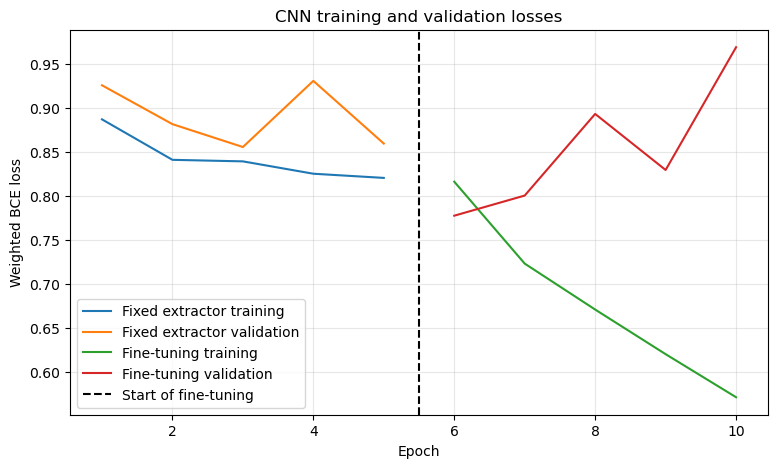

In [85]:
plt.figure(figsize=(9, 5))

plt.plot(fixed_epochs, fixed_train_losses, label="Fixed extractor training")

plt.plot(fixed_epochs, fixed_val_losses, label="Fixed extractor validation")

plt.plot(fine_tune_epochs, fine_tune_train_losses, label="Fine-tuning training")

plt.plot(fine_tune_epochs, fine_tune_val_losses, label="Fine-tuning validation")

plt.axvline(
len(fixed_train_losses) + 0.5,
    color="black",
    linestyle="--",
    label="Start of fine-tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted BCE loss")
plt.title("CNN training and validation losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The fixed feature extractor showcased a general decrease in both training and validation loss which indicates that the new classification head learned useful information from the frozen pretrained features. The validation loss did fluctuate slightly but ended lower than at the beginning of this stage.

During fine tuning, the training loss still decreased substantially from approximately 0.8167 to 0.5717. However, the validation loss fluctuated and ended up increasing overall, ending at approximately 0.9695. The divergence between decreasing training loss and increasing validation loss suggests overfitting that happened during fine-tuning. The model was adapting closely to the training images but not achieving consistent improvement on unseen validation images.

Seed control. Set and report all random seeds. Retrain your headline configuration using at least three
different seeds. Report the mean and standard deviation of your primary metric. When claiming that the
CNN outperforms the baseline, state whether the improvement is larger than the observed run-to-run variation.

In [86]:
%%skipif E5_CHECKPOINT.exists()

seeds = [42, 123, 2024]

seed_results = []

for seed in seeds:
    print(f"\nStarting seed {seed}")
    result = run_cnn_seed(seed, train_dataset, val_dataset, weighted_loss)
    seed_results.append(result)

    print(
        f"Seed {seed} validation PR-AUC: "
        f"{result['validation_metrics']['pr_auc']:.4f}"
    )

Skipping cell execution because condition 'E5_CHECKPOINT.exists()' is True.


In [87]:
# Load the best model checkpoint if it exists
if E5_CHECKPOINT.exists():
    e5_checkpoint = torch.load(
        E5_CHECKPOINT,
        map_location="cpu",
        weights_only=False
    )

    seeds = e5_checkpoint["seeds"]
    seed_results = e5_checkpoint["seed_results"]
    seed_summary = e5_checkpoint["seed_summary"]
    seed_metric_table = e5_checkpoint["seed_metric_table"]
    primary_metric_mean = e5_checkpoint["primary_metric_mean"]
    primary_metric_std = e5_checkpoint["primary_metric_std"]

    print("Loaded E.5 results. Seed retraining skipped.")

Loaded E.5 results. Seed retraining skipped.


In [88]:
# Calculating mean and standard deviation of PR-AUC across seeds
seed_pr_auc = np.array([
    result["validation_metrics"]["pr_auc"]
    for result in seed_results
])

seed_summary = pd.DataFrame({
    "Seed": seeds,
    "Validation PR-AUC": seed_pr_auc
})

seed_summary

,Seed,Validation PR-AUC
0,42,0.592363
1,123,0.587527
2,2024,0.580896


In [89]:
primary_metric_mean = seed_pr_auc.mean()
primary_metric_std = seed_pr_auc.std(ddof=1)

print("Mean validation PR-AUC:", primary_metric_mean)
print("Standard deviation:", primary_metric_std)

Mean validation PR-AUC: 0.5869287114685035
Standard deviation: 0.005756488776945291


In [90]:
seed_metric_table = pd.DataFrame([
    {
        "Seed": result["seed"],
        "Accuracy": result["validation_metrics"]["accuracy"],
        "Sensitivity": result["validation_metrics"]["sensitivity"],
        "Specificity": result["validation_metrics"]["specificity"],
        "Precision": result["validation_metrics"]["precision"],
        "F1-score": result["validation_metrics"]["f1"],
        "ROC-AUC": result["validation_metrics"]["roc_auc"],
        "PR-AUC": result["validation_metrics"]["pr_auc"]
    }
    for result in seed_results
])

seed_metric_table

,Seed,Accuracy,Sensitivity,Specificity,Precision,F1-score,ROC-AUC,PR-AUC
0,42,0.782239,0.688671,0.808081,0.497743,0.577844,0.833547,0.592363
1,123,0.778378,0.704728,0.798719,0.491599,0.579179,0.833216,0.587527
2,2024,0.750193,0.756467,0.748460,0.453719,0.567224,0.832799,0.580896


The CNN configuration was retrained using three seeds: 42, 123 and 2024. The same data splits, preprocessing, augmentation, loss function, learning rates, etc. were used for each run. Validation PR-AUC was reported as the primary metric because the positive class is imbalanced.

The validation PR-AUC values were 0.5924 for seed 42, 0.5875 for seed 123 and 0.5809 for seed 2024. The mean validation PR-AUC is 0.5869 and we observe a standard deviation of 0.0058. This indicates a very small run-to-run variation across the three sets. The simple baseline validation PR-AUC was 0.2266. The CNN therefore did improve the primary metric by approximately 0.3603 compared to the simple baseline. This improvement is also substantially larger than the observed standard deviation of 0.0058, which suggests that the improvement is larger than the run-to-run variation we observed in these experiments. However, something to note is that this comparison is based on validation performance and should not be treated as a final test-set claim until the CNN is evaluated on the untouched final set.

### Part F. Evaluate performance

From the predicted probabilities, report a confusion matrix, accuracy, sensitivity, specificity, precision and F1-score.

In [91]:
test_dataset = ChestXrayDataset(
    test_features_df
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Test images:", len(test_dataset))

Test images: 5164


In [92]:
# using the best seed model for final evaluation on the test set
headline_cnn = seed_results[0]["model"]
headline_cnn.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [93]:
# generating test probabilities and predictions
cnn_test_probabilities = []
cnn_test_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        logits = headline_cnn(images).squeeze(1)
        probabilities = torch.sigmoid(logits)

        cnn_test_probabilities.extend(
            probabilities.cpu().numpy()
        )

        cnn_test_labels.extend(
            labels_batch.cpu().numpy()
        )

cnn_test_probabilities = np.asarray(cnn_test_probabilities)
cnn_test_labels = np.asarray(cnn_test_labels)

cnn_test_predictions = (
    cnn_test_probabilities >= 0.5
).astype(int)

print("CNN test probabilities generated.")
print("Number of test predictions:", len(cnn_test_predictions))

CNN test probabilities generated.
Number of test predictions: 5164


In [94]:
cnn_test_metrics = calculate_metrics(
    labels=cnn_test_labels,
    predictions=cnn_test_predictions,
    probabilities=cnn_test_probabilities
)

print("CNN test confusion matrix:")
print(cnn_test_metrics["confusion_matrix"])

print("\nCNN test metrics:")
print("Accuracy:", cnn_test_metrics["accuracy"])
print("Sensitivity:", cnn_test_metrics["sensitivity"])
print("Specificity:", cnn_test_metrics["specificity"])
print("Precision:", cnn_test_metrics["precision"])
print("F1-score:", cnn_test_metrics["f1"])

CNN test confusion matrix:
[[3173  769]
 [ 332  890]]

CNN test metrics:
Accuracy: 0.7867931835786213
Sensitivity: 0.7283142389525368
Specificity: 0.8049213597158803
Precision: 0.5364677516576251
F1-score: 0.6178410274210344


Present the trivial baseline, simple baseline and CNN in one comparison table, using identical splits and metrics.

In [95]:
test_majority_predictions = np.full(
    len(test_labels),
    majority_class
)

trivial_test_metrics = calculate_metrics(
    labels=test_labels,
    predictions=test_majority_predictions
)

In [96]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Trivial majority baseline",
        "Accuracy": trivial_test_metrics["accuracy"],
        "Sensitivity": trivial_test_metrics["sensitivity"],
        "Specificity": trivial_test_metrics["specificity"],
        "Precision": trivial_test_metrics["precision"],
        "F1-score": trivial_test_metrics["f1"],
        "ROC-AUC": np.nan,
        "PR-AUC": np.nan
    },
    {
        "Model": "Simple feature baseline",
        "Accuracy": final_test_metrics["accuracy"],
        "Sensitivity": final_test_metrics["sensitivity"],
        "Specificity": final_test_metrics["specificity"],
        "Precision": final_test_metrics["precision"],
        "F1-score": final_test_metrics["f1"],
        "ROC-AUC": final_test_metrics["roc_auc"],
        "PR-AUC": final_test_metrics["pr_auc"]
    },
    {
        "Model": "CNN",
        "Accuracy": cnn_test_metrics["accuracy"],
        "Sensitivity": cnn_test_metrics["sensitivity"],
        "Specificity": cnn_test_metrics["specificity"],
        "Precision": cnn_test_metrics["precision"],
        "F1-score": cnn_test_metrics["f1"],
        "ROC-AUC": cnn_test_metrics["roc_auc"],
        "PR-AUC": cnn_test_metrics["pr_auc"]
    }
])

final_model_comparison

,Model,Accuracy,Sensitivity,Specificity,Precision,F1-score,ROC-AUC,PR-AUC
0,Trivial majority baseline,0.763362,0.000000,1.000000,0.000000,0.000000,NaN,NaN
1,Simple feature baseline,0.698490,0.149755,0.868595,0.261056,0.190328,0.497918,0.248675
2,CNN,0.786793,0.728314,0.804921,0.536468,0.617841,0.854948,0.657099


Plot the receiver operating characteristic (ROC) and precision–recall curves and report the area under each curve. Explain which curve is more informative for the observed class balance and why. 

In [97]:
simple_test_curves = calculate_curves(
    labels=test_labels,
    probabilities=test_probabilities
)

cnn_test_curves = calculate_curves(
    labels=cnn_test_labels,
    probabilities=cnn_test_probabilities
)

print("Simple baseline ROC-AUC:", simple_test_curves["roc_auc"])
print("Simple baseline PR-AUC:", simple_test_curves["pr_auc"])
print("CNN ROC-AUC:", cnn_test_curves["roc_auc"])
print("CNN PR-AUC:", cnn_test_curves["pr_auc"])

Simple baseline ROC-AUC: 0.49791846753374003
Simple baseline PR-AUC: 0.2479218916906117
CNN ROC-AUC: 0.8549479938652192
CNN PR-AUC: 0.6564723447105182


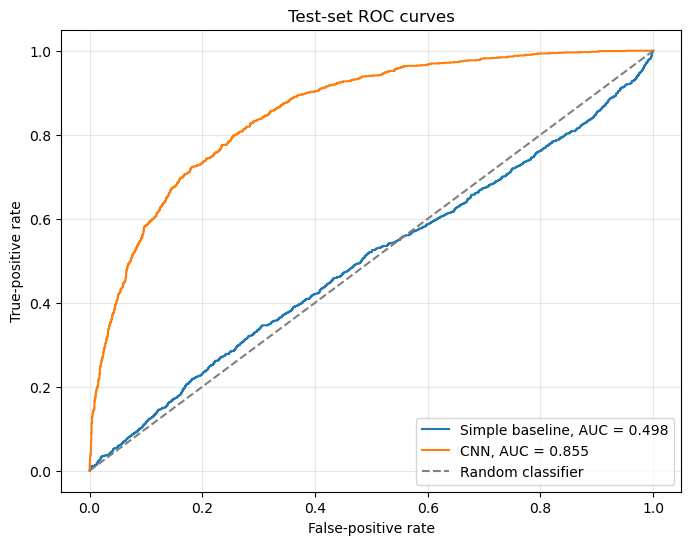

In [98]:
# ROC-AUC curves

plt.figure(figsize=(8, 6))

plt.plot(
    simple_test_curves["fpr"],
    simple_test_curves["tpr"],
    label=f"Simple baseline, AUC = {simple_test_curves['roc_auc']:.3f}"
)

plt.plot(
    cnn_test_curves["fpr"],
    cnn_test_curves["tpr"],
    label=f"CNN, AUC = {cnn_test_curves['roc_auc']:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("Test-set ROC curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

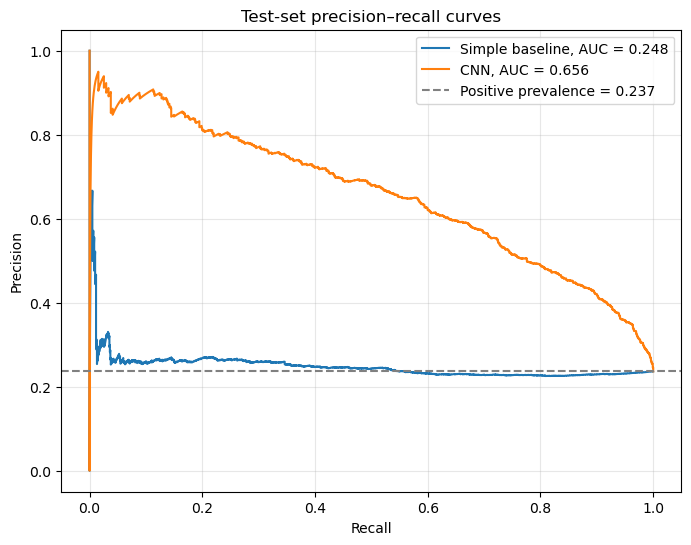

In [99]:
# PR-AUC curves
test_prevalence = cnn_test_labels.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    simple_test_curves["recall"],
    simple_test_curves["precision"],
    label=f"Simple baseline, AUC = {simple_test_curves['pr_auc']:.3f}"
)

plt.plot(
    cnn_test_curves["recall"],
    cnn_test_curves["precision"],
    label=f"CNN, AUC = {cnn_test_curves['pr_auc']:.3f}"
)

plt.axhline(
    test_prevalence,
    linestyle="--",
    color="gray",
    label=f"Positive prevalence = {test_prevalence:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test-set precision–recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The ROC curve depicts the trade-off between the true-positive rate (TPR) and false-positive (FPR) across classification thresholds. ROC-AUC measures the model's ability to rank positive examinations above negative examinations. The PR curve shows the trade-off between precision and recall. It is more informative for this dataset because the positive class itself is less common than the negative class. Precision reflects how many predicted positive examinations were actually positive, while recall reflects on how many positive examinations were detected to begin with. The dashed horizontal line represents the positive-class prevalence in the test set.

Therefore, PR-AUC is more important for assessing performance on the less common positive class, while ROC-AUC provides a broader measure of threshold-independent discrimination.

Select two operating thresholds using only the validation set: a screening threshold prioritizing sensitivity and a high-specificity threshold. State the rule used to select each threshold, freeze both thresholds and apply them to the test set.

In [100]:
# cnn validation probabilities
headline_cnn.eval()

cnn_val_probabilities = []
cnn_val_labels = []

with torch.no_grad():
    for images, labels_batch in val_loader:
        logits = headline_cnn(images).squeeze(1)
        probabilities = torch.sigmoid(logits)

        cnn_val_probabilities.extend(
            probabilities.cpu().numpy()
        )

        cnn_val_labels.extend(
            labels_batch.cpu().numpy()
        )

cnn_val_probabilities = np.asarray(cnn_val_probabilities)
cnn_val_labels = np.asarray(cnn_val_labels)

In [101]:
# Selecting a screening threshold for the CNN model based on validation sensitivity

screening_threshold_candidates = np.linspace(
    0.01,
    0.99,
    99
)

screening_threshold = None

for threshold in screening_threshold_candidates:
    predictions = (
        cnn_val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        cnn_val_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    if sensitivity >= 0.80:
        screening_threshold = threshold

if screening_threshold is None:
    raise ValueError(
        "No screening threshold achieved at least 80% sensitivity."
    )

print("Screening threshold:", screening_threshold)

Screening threshold: 0.31


In [102]:
# Selecting a specificity threshold for the CNN model based on validation specificity
specificity_threshold_candidates = np.linspace(
    0.01,
    0.99,
    99
)

high_specificity_threshold = None

for threshold in specificity_threshold_candidates:
    predictions = (
        cnn_val_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        cnn_val_labels,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    if specificity >= 0.90:
        high_specificity_threshold = threshold
        break

if high_specificity_threshold is None:
    raise ValueError(
        "No threshold achieved at least 90% specificity."
    )

print(
    "High-specificity threshold:",
    high_specificity_threshold
)

High-specificity threshold: 0.72


In [103]:
# applying chosen thresholds to the test set
screening_test_predictions = (
    cnn_test_probabilities >= screening_threshold
).astype(int)

high_specificity_test_predictions = (
    cnn_test_probabilities >= high_specificity_threshold
).astype(int)

In [104]:
screening_test_metrics = calculate_metrics(
    labels=cnn_test_labels,
    predictions=screening_test_predictions,
    probabilities=cnn_test_probabilities
)

high_specificity_test_metrics = calculate_metrics(
    labels=cnn_test_labels,
    predictions=high_specificity_test_predictions,
    probabilities=cnn_test_probabilities
)

In [105]:
threshold_results = pd.DataFrame([
    {
        "Operating point": "Screening",
        "Threshold": screening_threshold,
        "Accuracy": screening_test_metrics["accuracy"],
        "Sensitivity": screening_test_metrics["sensitivity"],
        "Specificity": screening_test_metrics["specificity"],
        "Precision": screening_test_metrics["precision"],
        "F1-score": screening_test_metrics["f1"]
    },
    {
        "Operating point": "High specificity",
        "Threshold": high_specificity_threshold,
        "Accuracy": high_specificity_test_metrics["accuracy"],
        "Sensitivity": high_specificity_test_metrics["sensitivity"],
        "Specificity": high_specificity_test_metrics["specificity"],
        "Precision": high_specificity_test_metrics["precision"],
        "F1-score": high_specificity_test_metrics["f1"]
    }
])

threshold_results

,Operating point,Threshold,Accuracy,Sensitivity,Specificity,Precision,F1-score
0,Screening,0.31,0.736832,0.832242,0.707255,0.468448,0.599469
1,High specificity,0.72,0.823199,0.587561,0.896246,0.637090,0.611324


The screening threshold was selected using the validation set to achieve atleast 80% sensitivity. The selected threshold was 0.31. When applied to the untouched test set, it achieves a sensitivity of 0.8322 and a specificity of 0.7073, precision of 0.4684, and an F1-score of 0.5995. This operating point detected more positive examinations but also produced more false positives and therefore had lower specificity. The high specificity threshold was selected to achieve atleast 90% specificity. The selected threshold was 0.72. When applied to the test set, it achieved a specificity of 0.8962, sensitivity of 0.5876, precision of 0.6371, accuracy of 0.8232 and an F1-score of 0.6113. This operating point reduced false positives, but it also missed more positive examinations than the screening threshold.

These results showcase the expected trade-off between sensitivity and specificity. The screening threshold is more suitable when missing positive cases is the greater concern, but the high-specificity threshold is more suitable when reducing false positives is important.

Plot a reliability diagram and explain the difference between discrimination and calibration. 

In [106]:
cnn_fraction_of_positives, cnn_mean_predicted_value = calibration_curve(
    cnn_test_labels,
    cnn_test_probabilities,
    n_bins=10,
    strategy="uniform"
)

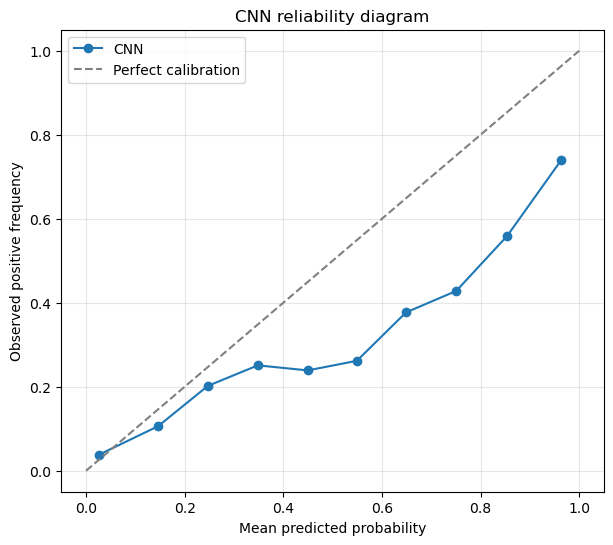

In [107]:
plt.figure(figsize=(7, 6))

plt.plot(
    cnn_mean_predicted_value,
    cnn_fraction_of_positives,
    marker="o",
    label="CNN"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive frequency")
plt.title("CNN reliability diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The CNN reliability diagram depicts that most points lie below the perfect-calibration line. This indicates that the CNN is mostly over-confident, because its predicted probabilities are higher than the observed positive-class frequency. The lowest-probability point is close to the diagonal which suggests reasonable calibration for very low predicted probabilities. However, the gap from the diagonal keeps on increasing at higher predicted probabilities which indicates poorer calibration in the high-confidence region. The small fluctuation that happens in the middle of the curve is expected because each bin only contains a finite number of test examples.

Discrimination and calibration measure different properties. Discrimination describes how well the CNN ranks the positive examinations above negative examinations, which uses measures such as ROC-AUC and PR-AUC. On the other hand, calibration describes whether predicted probabilities correspond to observed frequencies. Therefore, a model can discriminate well while being over-confident or poorly calibrated at the same time. This particular CNN appears to have useful discrimination but requires probability calibration if its output probabilities are expected to be used quantitatively.

### Part G. Interpret predictions and analyse errors

Display representative true-positive, true-negative, false-positive and false-negative examples. 

In [108]:
test_results = test_features_df.copy()

test_results["true_label"] = cnn_test_labels.astype(int)
test_results["predicted_label"] = cnn_test_predictions
test_results["predicted_probability"] = cnn_test_probabilities

conditions = [
    (test_results["true_label"] == 1)
    & (test_results["predicted_label"] == 1),
    (test_results["true_label"] == 0)
    & (test_results["predicted_label"] == 0),
    (test_results["true_label"] == 0)
    & (test_results["predicted_label"] == 1),
    (test_results["true_label"] == 1)
    & (test_results["predicted_label"] == 0),
]

outcome_names = [
    "True positive",
    "True negative",
    "False positive",
    "False negative",
]

test_results["prediction_type"] = np.select(
    conditions,
    outcome_names,
    default="Other"
)

representative_examples = (
    test_results[
        test_results["prediction_type"].isin(outcome_names)
    ]
    .groupby("prediction_type", sort=False)
    .head(1)
)

representative_examples[
    [
        "patientId",
        "true_label",
        "predicted_label",
        "predicted_probability",
        "prediction_type",
    ]
]

,patientId,true_label,predicted_label,predicted_probability,prediction_type
0,1.2.276.0.7230010.3.1.4.8323329.10018.15178743...,0,1,0.929606,False positive
1,1.2.276.0.7230010.3.1.4.8323329.10021.15178743...,0,0,0.245200,True negative
5,1.2.276.0.7230010.3.1.4.8323329.10029.15178743...,1,1,0.986626,True positive
19,1.2.276.0.7230010.3.1.4.8323329.10127.15178743...,1,0,0.042879,False negative


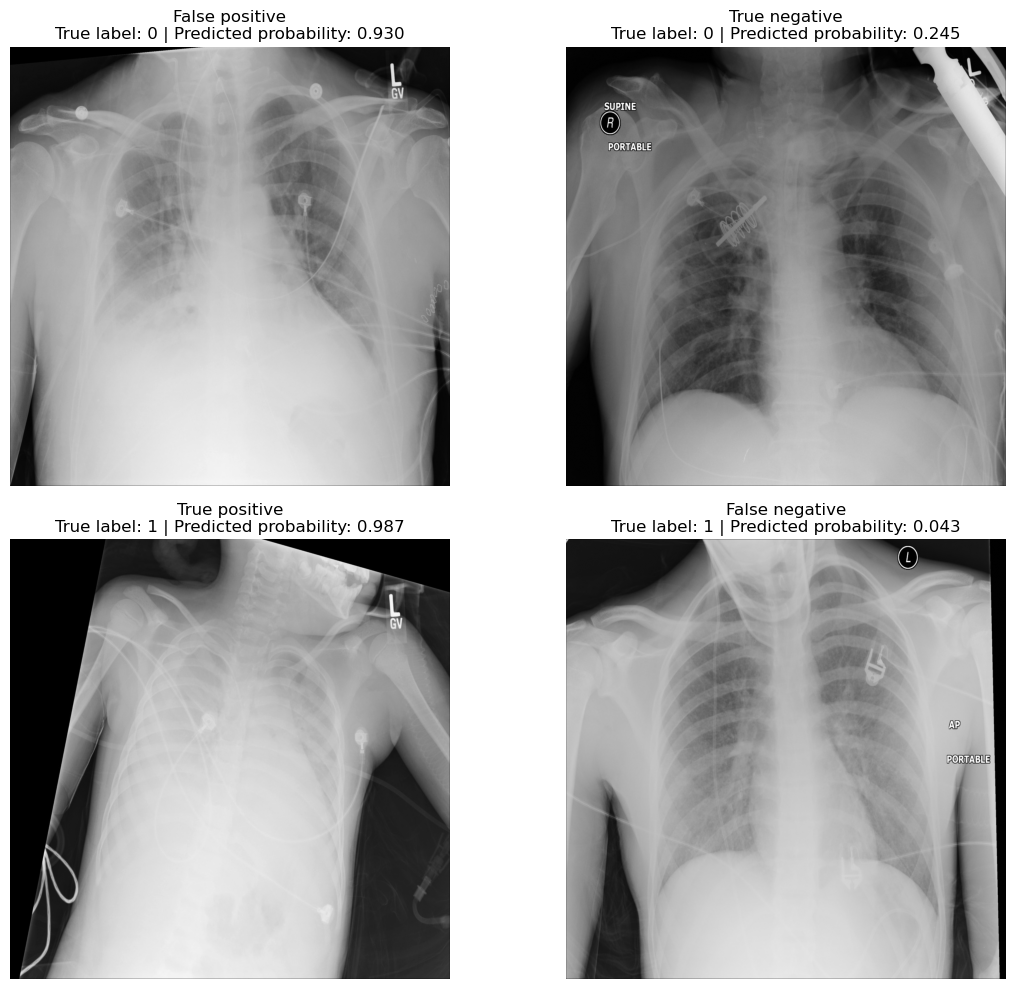

In [109]:
# Display the four images
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (_, row) in zip(
    axes.flatten(),
    representative_examples.iterrows()
):
    dicom = pydicom.dcmread(row["image_path"])

    colour_map = (
        "gray_r"
        if dicom.get("PhotometricInterpretation") == "MONOCHROME1"
        else "gray"
    )

    ax.imshow(dicom.pixel_array, cmap=colour_map)

    ax.set_title(
        f"{row['prediction_type']}\n"
        f"True label: {row['true_label']} | "
        f"Predicted probability: {row['predicted_probability']:.3f}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Report performance for at least one available subgroup, such as AP versus PA projection or patient sex. Report the subgroup sizes and interpret results from small groups cautiously. 

In [110]:
# we need to extract projection metadata
def get_view_position(path):
    dicom = pydicom.dcmread(path, stop_before_pixels=True)
    return dicom.get("ViewPosition", "Unknown")

subgroup_results = test_features_df.copy()

subgroup_results["ViewPosition"] = (
    subgroup_results["image_path"]
    .map(get_view_position)
    .fillna("Unknown")
)

subgroup_results["true_label"] = cnn_test_labels.astype(int)
subgroup_results["predicted_label"] = cnn_test_predictions
subgroup_results["predicted_probability"] = cnn_test_probabilities

print(subgroup_results["ViewPosition"].value_counts())

ViewPosition
PA    2762
AP    2402
Name: count, dtype: int64


In [111]:
# calculating AP and PA metrics
projection_rows = []

for projection in ["AP", "PA"]:
    subgroup = subgroup_results[
        subgroup_results["ViewPosition"] == projection
    ]

    if subgroup.empty:
        continue

    labels = subgroup["true_label"].to_numpy()
    predictions = subgroup["predicted_label"].to_numpy()
    probabilities = subgroup["predicted_probability"].to_numpy()

    metrics = calculate_metrics(
        labels=labels,
        predictions=predictions,
        probabilities=probabilities
    )

    projection_rows.append({
        "Projection": projection,
        "Sample size": len(subgroup),
        "Positive count": int(labels.sum()),
        "Positive proportion": labels.mean(),
        "Accuracy": metrics["accuracy"],
        "Sensitivity": metrics["sensitivity"],
        "Specificity": metrics["specificity"],
        "Precision": metrics["precision"],
        "F1-score": metrics["f1"],
        "ROC-AUC": metrics["roc_auc"],
        "PR-AUC": metrics["pr_auc"]
    })

projection_comparison = pd.DataFrame(projection_rows)
projection_comparison

,Projection,Sample size,Positive count,Positive proportion,Accuracy,Sensitivity,Specificity,Precision,F1-score,ROC-AUC,PR-AUC
0,AP,2402,975,0.405912,0.706495,0.802051,0.641205,0.604328,0.689290,0.804838,0.729061
1,PA,2762,247,0.089428,0.856626,0.437247,0.897813,0.295890,0.352941,0.810344,0.312267


CNN performance clearly differed between the AP and PA projections. The AP subgroup had 2402 examinations which included 975 positive cases, giving a positive proportion of 0.4059. The PA subgroup contained 2762 examinations which included 247 positive cases and therefore had a much lower positive proportion of 0.0894. For AP images, the CNN achieved an accuracy of 0.7065, a sensitivity of 0.8021, specificity of 0.6412, precision of 0.6043 and F1-score of 0.6893. For PA images, it achieved an accuracy of 0.8566, sensitivity of 0.4372, specificity of 0.8978, precision of 0.2959 and F1-score of 0.3529

The ROC-AUC values were similar for AP and PA images with 0.8048 and 0.8103 respectively which suggested a comparable ranking discrimination. However, the PR-AUC of PA images was much lower than the PR-AUC of AP images which came out at 0.3123 compared to 0.7291. This difference was strongly influenced by the different positive-class observations we observed earlier in the two subgroups. The model detected more positive cases in AP but also produced more false positives, it was more conservative for PA images and also achieved a higher specificity but overall lower sensitivity.

Produce Grad-CAM visualizations for at least four images, including at least one correct and one incorrect prediction. Name the model layer used for Grad-CAM and justify its selection. 

In [113]:
gradcam_examples = representative_examples.copy()

gradcam_examples["image_tensor"] = gradcam_examples["image_path"].map(
    lambda path: dicom_to_tensor(path).float()
)

target_layer = headline_cnn.layer4[-1]

print("Grad-CAM target layer:", target_layer)

Grad-CAM target layer: BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)


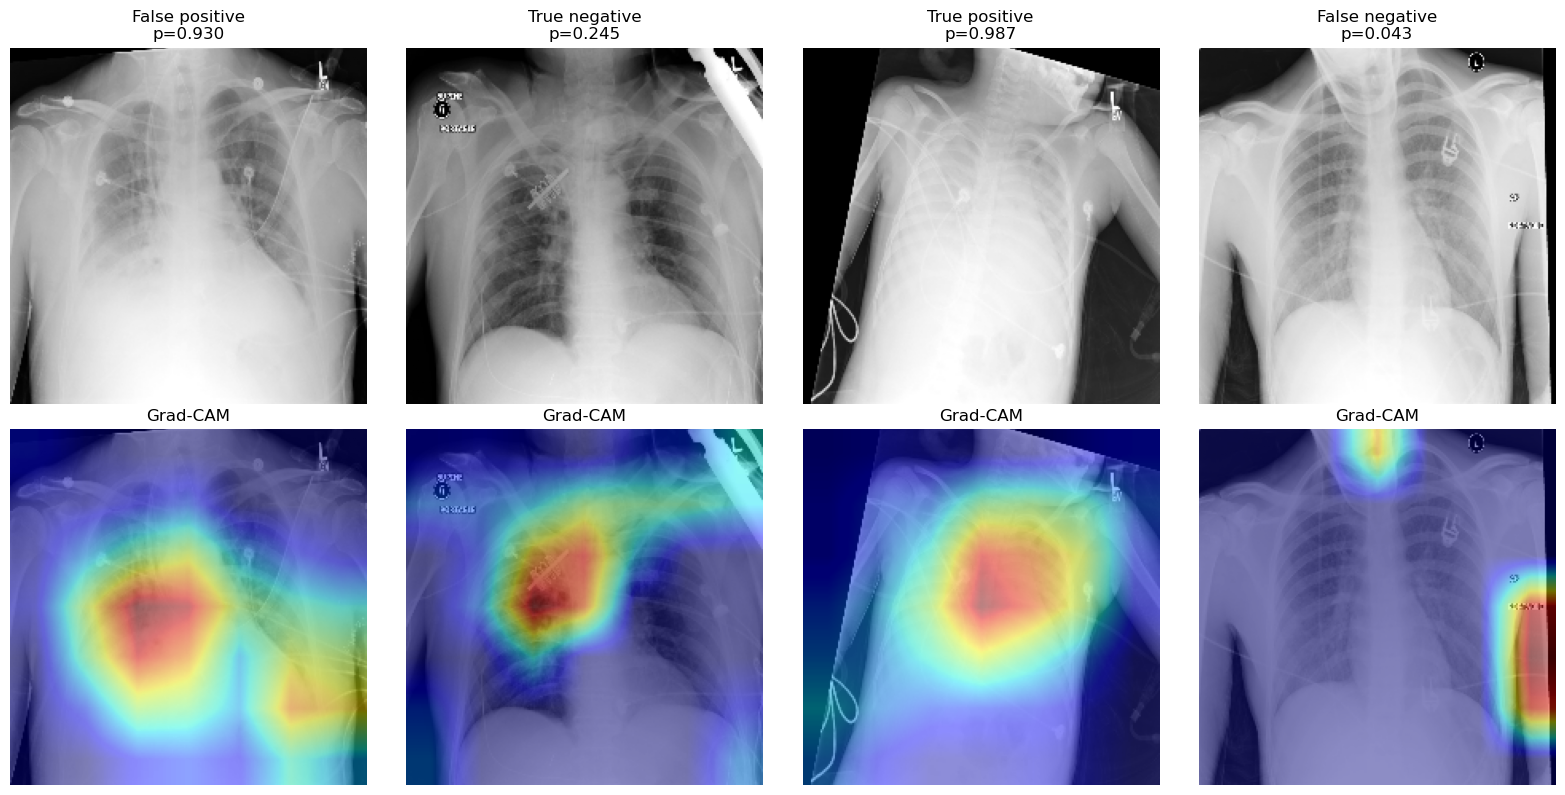

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for column, (_, row) in enumerate(
    gradcam_examples.iterrows()
):
    image_tensor = row["image_tensor"]

    cam, probability = generate_gradcam(
        model=headline_cnn,
        image_tensor=image_tensor,
        target_layer=target_layer
    )

    image = image_tensor.squeeze(0).numpy()

    axes[0, column].imshow(image, cmap="gray")
    axes[0, column].set_title(
        f"{row['prediction_type']}\n"
        f"p={probability:.3f}"
    )
    axes[0, column].axis("off")

    axes[1, column].imshow(image, cmap="gray")
    axes[1, column].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, column].set_title("Grad-CAM")
    axes[1, column].axis("off")

plt.tight_layout()
plt.show()

I used the final convolutional block, i.e headline_cnn.layer4[-1], from ResNet-18 for the Grad-CAM visualizations. I selected this layer because it contains high-level semantic features while still retaining spatial information needed to create a meaningful heatmap. Earlier layers do preserve more detail but capture lower-level patterns, while the fully connected classification head no longer has spatial dimensions. Therefore, layer4[-1] strikes a balance between semantic relevance and localization.

Discuss whether the model appears to focus on lung regions or possible shortcuts, such as image borders, markers or acquisition artefacts. Remember that Grad-CAM supports inspection but does not prove causation.

The Grad-CAM visualizations do suggest that the CNN often focuses on regions within or near the lungs, which is consistent with the intended task. However, some attention may also extend toward image borders, markers, acquisition-related artefacts, etc. These patterns may indicate that the model is using scanner or projection-specific signals in addition to clinically relevant lung information. This possibility is important to consider because the dataset contains both AP and PA projections, and the subgroup results showed different sensitivity, specificity and precision between these groups. The model may therefore be responding to acquisition characteristics or image quality differences associated with the projection type.
Grad-CAM is useful for inspecting the model attention but it does not provide causation itself. The highlighted regions indicate where the model's internal activations were pointing to but not necessarily which features definitely caused the prediction. Further testing would therefore require masking or perturbing suspected borders, markers, artefacts, etc. and then measure whether the predictions change. Performance should also be compared across acquisition sources and where possible, also on images from unseen hospitals or scanners.

## Bonus Parts

### Bonus A. Prevalence shift and threshold transfer.

In [119]:
# separating the classes

bonus_test_results = pd.DataFrame({
    "label": cnn_test_labels.astype(int),
    "probability": cnn_test_probabilities
})

positive_rows = bonus_test_results[bonus_test_results["label"] == 1]

negative_rows = bonus_test_results[bonus_test_results["label"] == 0]

print("Positive examples:", len(positive_rows))
print("Negative examples:", len(negative_rows))

Positive examples: 1222
Negative examples: 3942


In [121]:
target_10_positive_count = round(len(negative_rows) / 9)

positive_10_rows = positive_rows.sample(n=target_10_positive_count, random_state=42)

test_prevalence_10 = pd.concat([negative_rows, positive_10_rows], ignore_index=True)

target_40_negative_count = round(len(positive_rows) * 1.5)

negative_40_rows = negative_rows.sample(n=target_40_negative_count, random_state=42)

test_prevalence_40 = pd.concat([positive_rows, negative_40_rows], ignore_index=True)

print("10% subset prevalence:", test_prevalence_10["label"].mean())

print("40% subset prevalence:", test_prevalence_40["label"].mean())

10% subset prevalence: 0.1
40% subset prevalence: 0.4


In [122]:
# evaluating both subsets
def evaluate_bonus_subset(subset, threshold):
    labels = subset["label"].to_numpy()
    probabilities = subset["probability"].to_numpy()

    predictions = (
        probabilities >= threshold
    ).astype(int)

    metrics = calculate_metrics(
        labels=labels,
        predictions=predictions,
        probabilities=probabilities
    )

    return {
        "Positive prevalence": labels.mean(),
        "Sample size": len(labels),
        "Sensitivity": metrics["sensitivity"],
        "Specificity": metrics["specificity"],
        "Precision": metrics["precision"],
        "F1-score": metrics["f1"],
        "ROC-AUC": metrics["roc_auc"]
    }

In [123]:
# results table
bonus_a_results = pd.DataFrame([
    {
        "Test subset": "Approximately 10% positive",
        **evaluate_bonus_subset(
            test_prevalence_10,
            screening_threshold
        )
    },
    {
        "Test subset": "Approximately 40% positive",
        **evaluate_bonus_subset(
            test_prevalence_40,
            screening_threshold
        )
    }
])

bonus_a_results

,Test subset,Positive prevalence,Sample size,Sensitivity,Specificity,Precision,F1-score,ROC-AUC
0,Approximately 10% positive,0.1,4380,0.828767,0.707255,0.239288,0.371355,0.848676
1,Approximately 40% positive,0.4,3055,0.832242,0.706492,0.654019,0.732445,0.854897


Bonus A interpretation

Two additional test subsets were created by subsampling one class only from the original test set. The first subset had a positive prevalence of 10% and contained 4380 examinations. The second had a positive prevalence of 40% and contained 3055 examinations.

Sensitivity was very similar across the two subsets: 0.8288 at 10% prevalence and 0.8322 at 40% prevalence. Specificity was also almost unchanged, decreasing slightly from 0.7073 to 0.7065. ROC-AUC remained broadly similar, changing from 0.8487 to 0.8549. These small changes are expected because the same model scores were used and only one class was subsampled.

Precision changed substantially, increasing from 0.2393 at 10% prevalence to 0.6540 at 40% prevalence. F1-score also increased from 0.3714 to 0.7324 because it combines precision and sensitivity. Sensitivity is calculated among positive cases and specificity among negative cases, so changing prevalence alone should not systematically change them. Precision depends directly on prevalence because it measures the proportion of predicted positives that are actually positive.

This shows that a threshold validated on a challenge dataset may produce a much lower positive predictive value in an emergency department where pneumonia prevalence is lower. At 10% prevalence, most positive alerts were false positives despite the model's good sensitivity and ROC-AUC. The threshold would therefore require prospective validation and possibly recalibration before deployment in a lower-prevalence clinical setting.

### Bonus B. Shortcut stress test with a control.

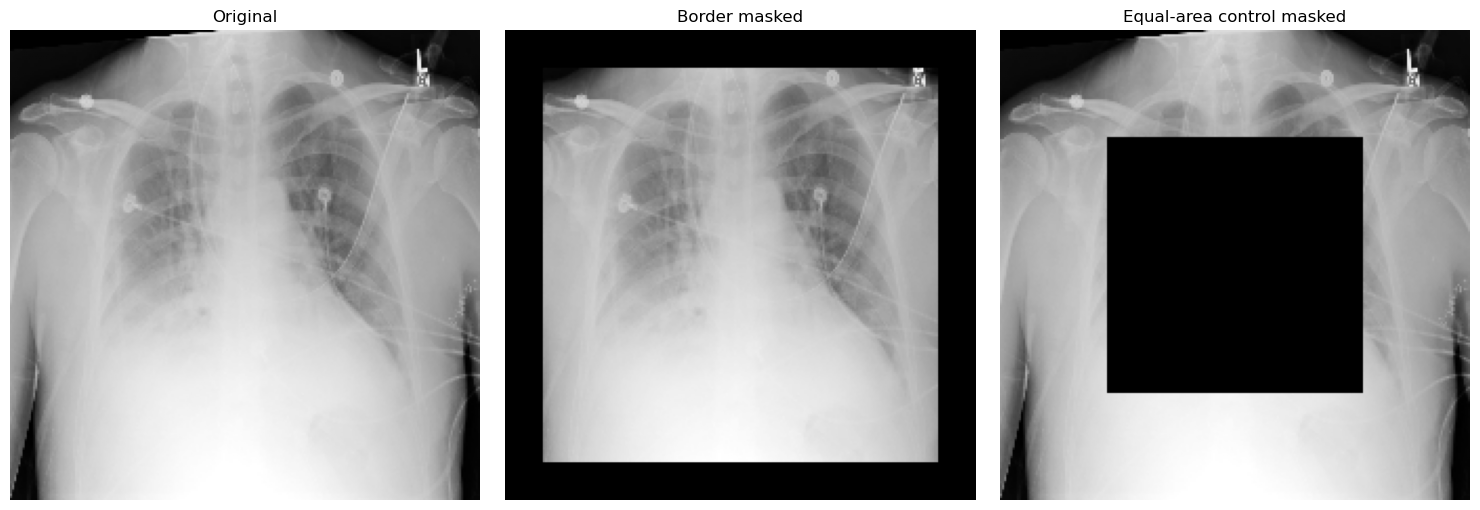

In [125]:
# testing the mask visually

bonus_sample = dicom_to_tensor(
    test_features_df.iloc[0]["image_path"]
).float()

border_masked_sample = mask_border(bonus_sample)
control_masked_sample = mask_control_region(bonus_sample)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bonus_sample.squeeze(0), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(border_masked_sample.squeeze(0), cmap="gray")
axes[1].set_title("Border masked")
axes[1].axis("off")

axes[2].imshow(control_masked_sample.squeeze(0), cmap="gray")
axes[2].set_title("Equal-area control masked")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [126]:
def predict_masked_images(model, image_paths, mask_function=None, batch_size=32):
    probabilities = []

    model.eval()

    with torch.no_grad():
        for start in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[start:start + batch_size]

            batch_images = []

            for path in batch_paths:
                image = dicom_to_tensor(path).float()

                if mask_function is not None:
                    image = mask_function(image)

                batch_images.append(image)

            batch_tensor = torch.stack(batch_images)

            logits = model(batch_tensor).squeeze(1)
            batch_probabilities = torch.sigmoid(logits)

            probabilities.extend(
                batch_probabilities.cpu().numpy()
            )

    return np.asarray(probabilities)

In [127]:
bonus_test_paths = test_features_df["image_path"].tolist()

bonus_original_probabilities = predict_masked_images(model=headline_cnn, image_paths=bonus_test_paths)

bonus_border_probabilities = predict_masked_images(
    model=headline_cnn,
    image_paths=bonus_test_paths,
    mask_function=mask_border
)

bonus_control_probabilities = predict_masked_images(
    model=headline_cnn,
    image_paths=bonus_test_paths,
    mask_function=mask_control_region
)

print("Original predictions:", len(bonus_original_probabilities))
print("Border-masked predictions:", len(bonus_border_probabilities))
print("Control-masked predictions:", len(bonus_control_probabilities))

Original predictions: 5164
Border-masked predictions: 5164
Control-masked predictions: 5164


In [128]:
bonus_border_delta = bonus_border_probabilities - bonus_original_probabilities

bonus_control_delta = bonus_control_probabilities- bonus_original_probabilities


bonus_border_absolute_delta = np.abs(bonus_border_delta)
bonus_control_absolute_delta = np.abs(bonus_control_delta)

print("Mean absolute border delta p:", bonus_border_absolute_delta.mean())

print("Mean absolute control delta p:", bonus_control_absolute_delta.mean())

Mean absolute border delta p: 0.13068795
Mean absolute control delta p: 0.25104913


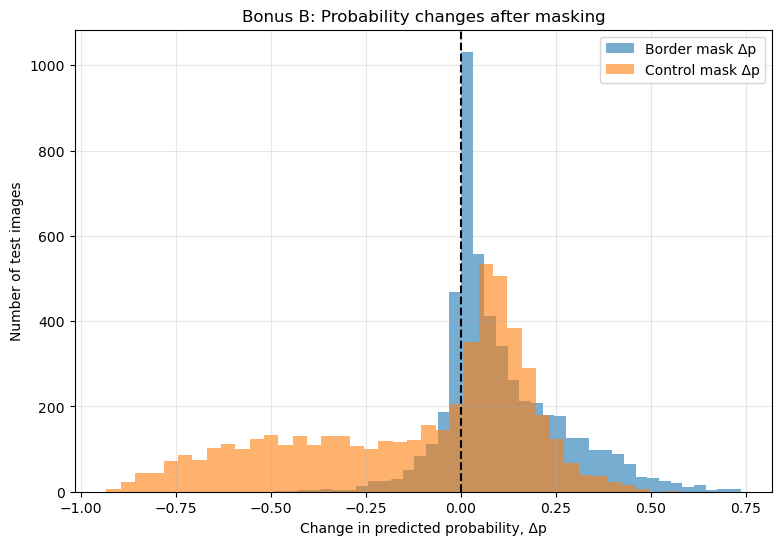

In [129]:
# comparing the distributions
plt.figure(figsize=(9, 6))

plt.hist(bonus_border_delta, bins=40, alpha=0.6, label="Border mask Δp")

plt.hist(bonus_control_delta, bins=40, alpha=0.6, label="Control mask Δp")

plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Change in predicted probability, Δp")
plt.ylabel("Number of test images")
plt.title("Bonus B: Probability changes after masking")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [130]:
# select the three largest absolute border effects

largest_border_effect_indices = np.argsort(bonus_border_absolute_delta)[-3:][::-1]

bonus_b_top_examples = test_features_df.iloc[largest_border_effect_indices].copy()

bonus_b_top_examples["original_probability"] = bonus_original_probabilities[largest_border_effect_indices]

bonus_b_top_examples["border_probability"] = bonus_border_probabilities[largest_border_effect_indices]

bonus_b_top_examples["border_delta"] = bonus_border_delta[largest_border_effect_indices]

bonus_b_top_examples[
    [
        "patientId",
        "original_probability",
        "border_probability",
        "border_delta"
    ]
]

,patientId,original_probability,border_probability,border_delta
1086,1.2.276.0.7230010.3.1.4.8323329.15857.15178743...,0.047787,0.784038,0.736251
3258,1.2.276.0.7230010.3.1.4.8323329.27577.15178744...,0.084229,0.815262,0.731033
1963,1.2.276.0.7230010.3.1.4.8323329.20651.15178744...,0.095701,0.822869,0.727167


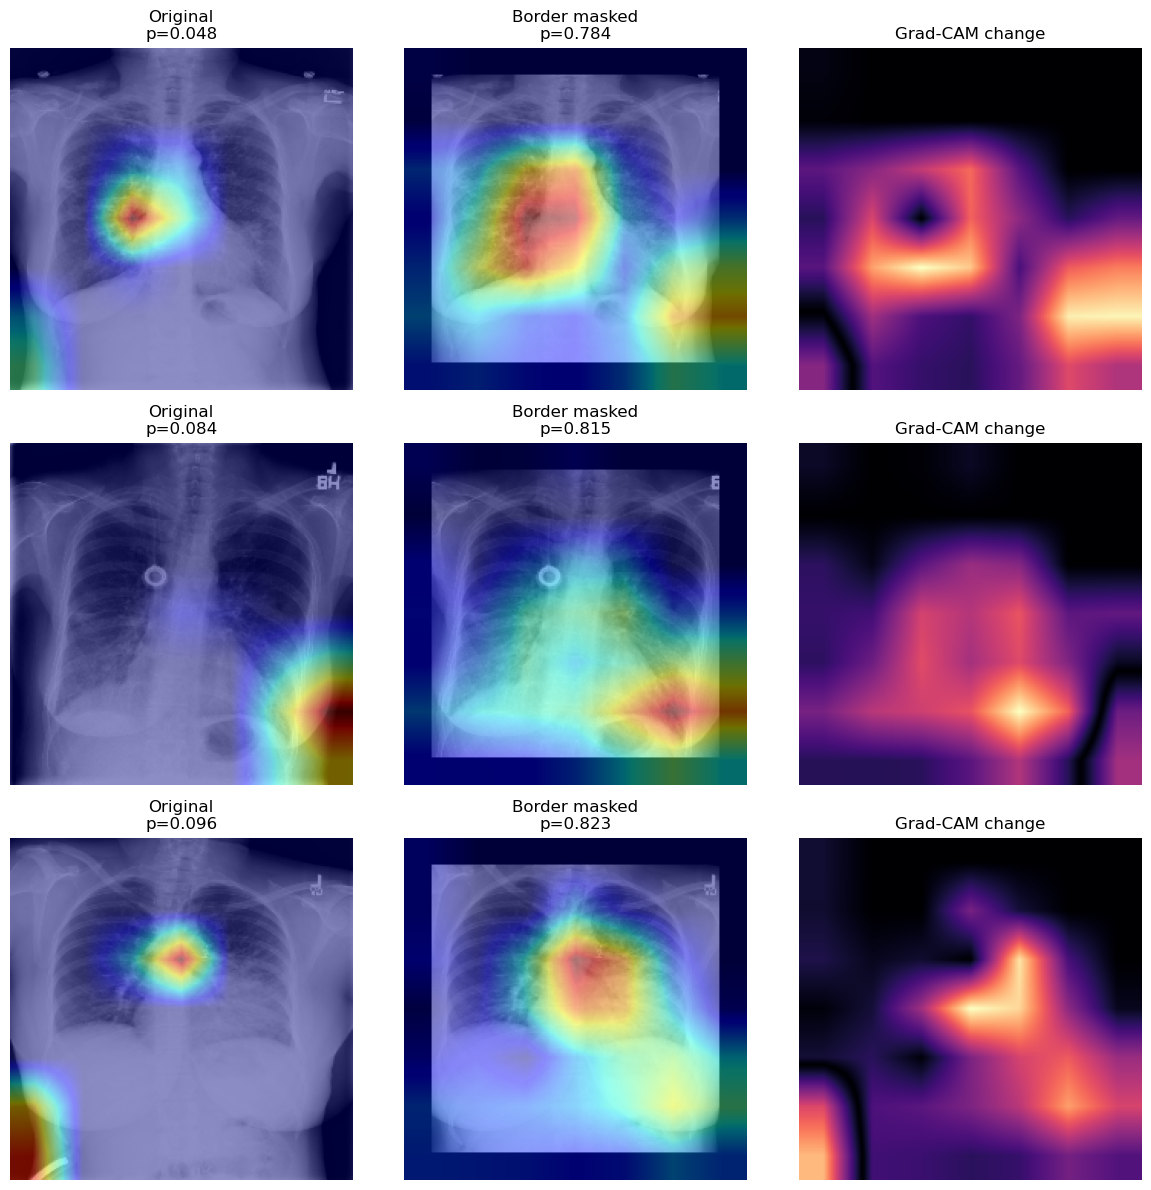

In [131]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row_number, (_, row) in enumerate(bonus_b_top_examples.iterrows()):
    original_image = dicom_to_tensor(row["image_path"]).float()

    masked_image = mask_border(original_image)

    original_cam, original_probability = generate_gradcam(model=headline_cnn, image_tensor=original_image, target_layer=target_layer)

    masked_cam, masked_probability = generate_gradcam(model=headline_cnn, image_tensor=masked_image, target_layer=target_layer)

    original_array = original_image.squeeze(0).numpy()
    masked_array = masked_image.squeeze(0).numpy()

    axes[row_number, 0].imshow(original_array, cmap="gray")
    axes[row_number, 0].imshow(original_cam, cmap="jet", alpha=0.45)
    axes[row_number, 0].set_title(f"Original\np={original_probability:.3f}")
    axes[row_number, 0].axis("off")

    axes[row_number, 1].imshow(masked_array, cmap="gray")
    axes[row_number, 1].imshow(masked_cam, cmap="jet", alpha=0.45)
    axes[row_number, 1].set_title(f"Border masked\np={masked_probability:.3f}")
    axes[row_number, 1].axis("off")

    axes[row_number, 2].imshow(np.abs(original_cam - masked_cam), cmap="magma")
    axes[row_number, 2].set_title("Grad-CAM change")
    axes[row_number, 2].axis("off")

plt.tight_layout()
plt.show()

Bonus B interpretation

The shortcut stress test compared the original test images with versions in which the outer 8% border was masked. An approximately equal-area central control region was also masked. The CNN was not retrained, and the same model was used for all predictions.

The mean absolute change in predicted probability was 0.1307 for the border mask and 0.2510 for the control mask. Therefore, masking the central control region changed the predictions more than masking the image border. The three images with the largest absolute border probability changes were inspected using Grad-CAM before and after masking.

The control is important because masking any substantial image region may change the prediction simply by removing information. In this experiment, the larger control effect suggests that the CNN was more affected by removing central image content than by removing the outer border. This does not provide evidence that the model relies primarily on border information.

However, the result does not prove that the model uses clinically meaningful anatomy. Both masks alter the image distribution and may create artificial patterns that were not present during training. Grad-CAM highlights regions associated with model activation but does not prove causation. The results therefore provide no strong evidence of a border-specific shortcut in this test, while supporting further investigation of central lung features and other acquisition artefacts.